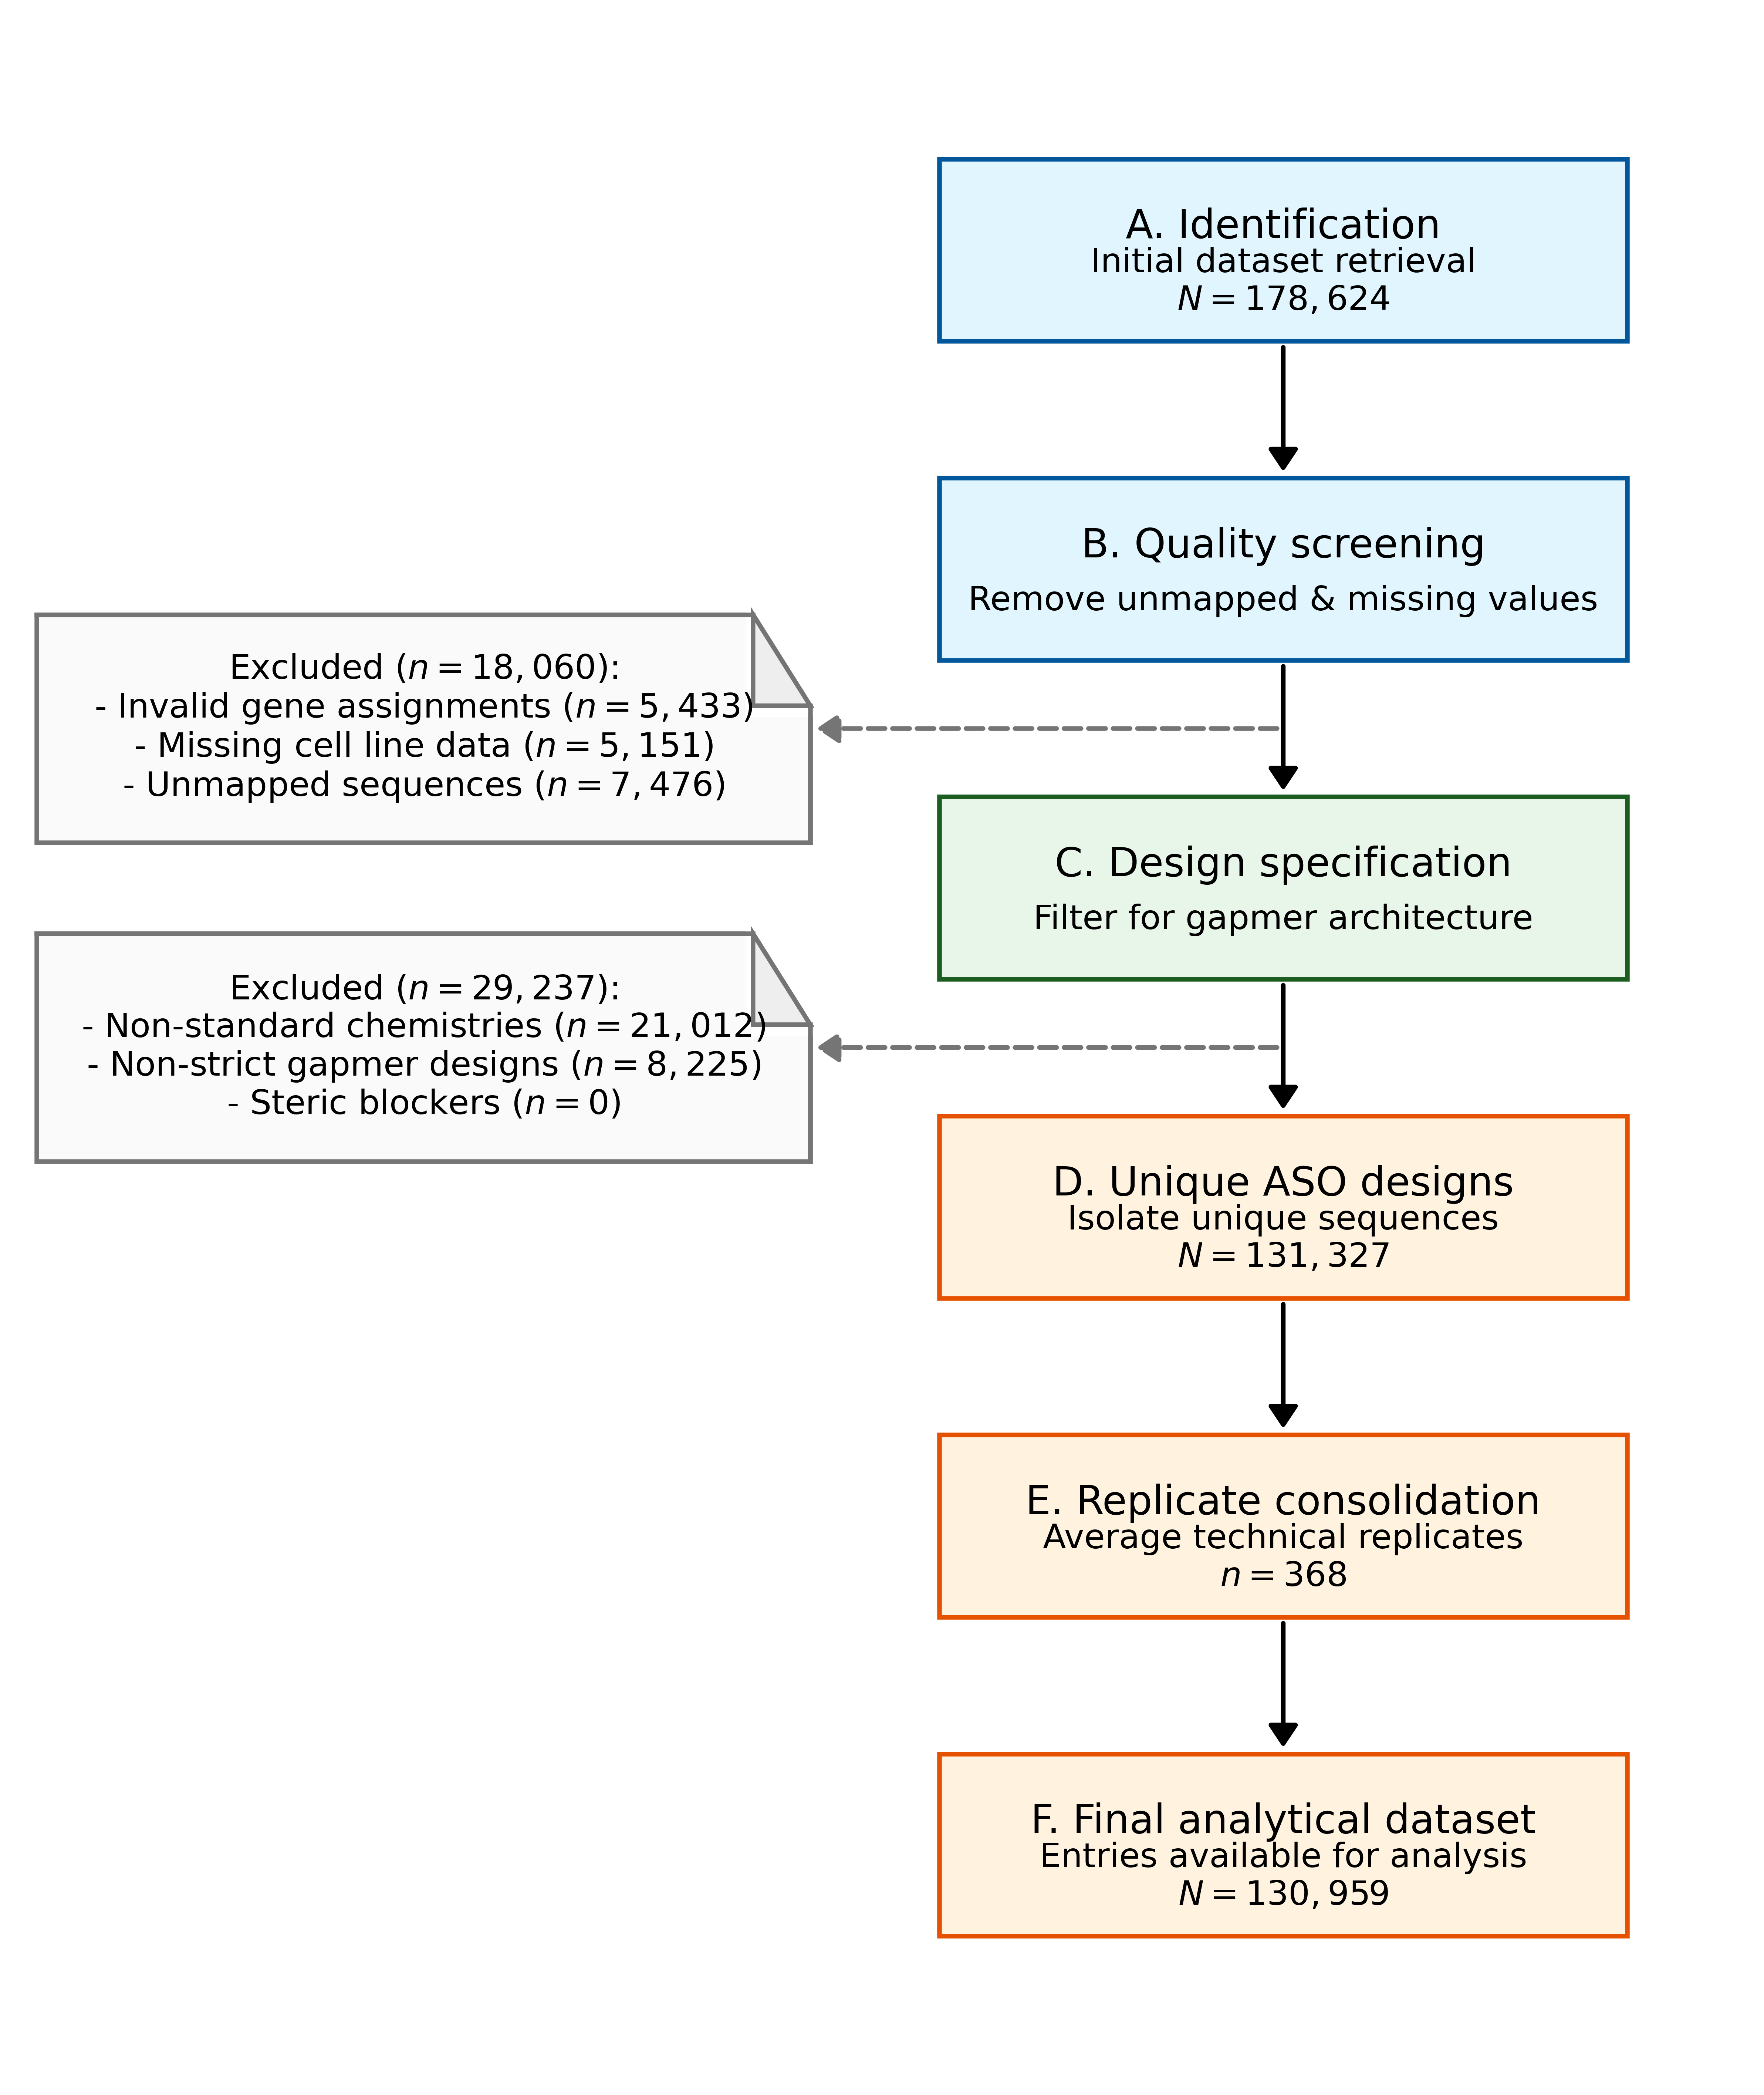

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Hardcode white background to override system dark mode
fig, ax = plt.subplots(figsize=(10, 12), dpi=600)
fig.patch.set_facecolor('#FFFFFF')
ax.set_facecolor('#FFFFFF')
ax.set_xlim(0, 120)
ax.set_ylim(10, 100)
ax.axis('off')

# Standard Light Mode Palette
style_ingest = {"facecolor": "#e1f5fe", "edgecolor": "#01579b"}
style_filter = {"facecolor": "#e8f5e9", "edgecolor": "#1b5e20"}
style_analytic = {"facecolor": "#fff3e0", "edgecolor": "#e65100"}
style_exc = {"facecolor": "#fafafa", "edgecolor": "#757575"}
text_color = "#000000"

def draw_box(x, y, w, h, text, style, is_exclusion=False):
    # Main Rectangle
    box = mpatches.Rectangle((x - w/2, y - h/2), w, h,
                             facecolor=style["facecolor"], edgecolor=style["edgecolor"], lw=1.5, zorder=2)
    ax.add_patch(box)

    lines = text.split('\n')

    if is_exclusion:
        ax.text(x, y, text, ha='center', va='center', family='sans-serif', size=11, color=text_color, zorder=4)

        # Corner fold visual
        fold_w = 4

        # Cover the corner with white
        corner_cover = mpatches.Rectangle((x+w/2-fold_w-0.5, y+h/2-fold_w-0.5), fold_w+1, fold_w+1,
                                          facecolor='#FFFFFF', edgecolor='none', zorder=2.5)
        ax.add_patch(corner_cover)

        # Draw the fold triangle
        fold = mpatches.Polygon([[x+w/2-fold_w, y+h/2], [x+w/2, y+h/2-fold_w], [x+w/2-fold_w, y+h/2-fold_w]],
                                closed=True, facecolor='#eeeeee', edgecolor=style["edgecolor"], lw=1.5, zorder=3)
        ax.add_patch(fold)

        # Re-stroke top and right edges up to the fold
        ax.plot([x-w/2, x+w/2-fold_w], [y+h/2, y+h/2], color=style["edgecolor"], lw=1.5, zorder=3)
        ax.plot([x+w/2, x+w/2], [y-h/2, y+h/2-fold_w], color=style["edgecolor"], lw=1.5, zorder=3)

    else:
        title = lines[0]
        body = '\n'.join(lines[1:])
        ax.text(x, y + (h/2)*0.25, title, ha='center', va='center', family='sans-serif', size=13, weight='normal', color=text_color, zorder=3)
        ax.text(x, y - (h/2)*0.35, body, ha='center', va='center', family='sans-serif', size=11, color=text_color, zorder=3)

# Pipeline text
A_text = "A. Identification\nInitial dataset retrieval\n$N = 178,624$"
B_text = "B. Quality screening\nRemove unmapped & missing values"
Exc_B_text = "Excluded ($n = 18,060$):\n- Invalid gene assignments ($n = 5,433$)\n- Missing cell line data ($n = 5,151$)\n- Unmapped sequences ($n = 7,476$)"
C_text = "C. Design specification\nFilter for gapmer architecture"
Exc_C_text = "Excluded ($n = 29,237$):\n- Non-standard chemistries ($n = 21,012$)\n- Non-strict gapmer designs ($n = 8,225$)\n- Steric blockers ($n = 0$)"
D_text = "D. Unique ASO designs\nIsolate unique sequences\n$N = 131,327$"
E_text = "E. Replicate consolidation\nAverage technical replicates\n$n = 368$"
F_text = "F. Final analytical dataset\nEntries available for analysis\n$N = 130,959$"

# Box dimensions and X coordinates
w_m, h_m = 48, 8
w_e, h_e = 54, 10
x_m = 88  # Shifted main boxes slightly right for better spacing
x_e = 28  # Left column for excluded boxes

# Y positions for main boxes
y_m = [90, 76, 62, 48, 34, 20]

# Y positions for exclusion boxes (perfectly centered between main steps)
y_exc_B = (y_m[1] + y_m[2]) / 2
y_exc_C = (y_m[2] + y_m[3]) / 2

# Render boxes
draw_box(x_m, y_m[0], w_m, h_m, A_text, style_ingest)
draw_box(x_m, y_m[1], w_m, h_m, B_text, style_ingest)
draw_box(x_e, y_exc_B, w_e, h_e, Exc_B_text, style_exc, is_exclusion=True)
draw_box(x_m, y_m[2], w_m, h_m, C_text, style_filter)
draw_box(x_e, y_exc_C, w_e, h_e, Exc_C_text, style_exc, is_exclusion=True)
draw_box(x_m, y_m[3], w_m, h_m, D_text, style_analytic)
draw_box(x_m, y_m[4], w_m, h_m, E_text, style_analytic)
draw_box(x_m, y_m[5], w_m, h_m, F_text, style_analytic)

# Helper function for drawing connections
def draw_arrow(x1, y1, x2, y2, color="black", ls="-"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>,head_width=0.4,head_length=0.6",
                                color=color, lw=1.5, ls=ls),
                zorder=1)

# Draw main vertical flow arrows
for i in range(5):
    draw_arrow(x_m, y_m[i] - h_m/2, x_m, y_m[i+1] + h_m/2)

# Draw dashed horizontal connections to the exclusion boxes
# Starts from the main vertical pipeline (x_m) and points to the right edge of the exclusion box (x_e + w_e / 2)
draw_arrow(x_m, y_exc_B, x_e + w_e/2, y_exc_B, color="#757575", ls="--")
draw_arrow(x_m, y_exc_C, x_e + w_e/2, y_exc_C, color="#757575", ls="--")

# Save with a hardcoded white facecolor to ensure it never exports as transparent/dark
plt.savefig('TAUSO_Pipeline_Connected.png', bbox_inches='tight', facecolor='#FFFFFF', transparent=False)